<a href="https://colab.research.google.com/github/rezkanorhafizah/ME-XBal/blob/main/notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Stage 1: Install Library

In [1]:
# Install library yang dibutuhkan (biasanya sudah tersedia di Colab)
!pip install -q transformers pandas numpy scikit-learn tqdm torch

#Stage 2: Loading Dataset & Preprocessing

📥 STAGE 1: LOADING DATASET BAHASA SUNDA (TRACK A)
✅ Dataset berhasil dimuat: 924 sampel
📊 Jumlah fitur emosi: 6

📈 DISTRIBUSI KELAS SEBELUM OVERSAMPLING:
----------------------------------------------------------------------
Class 0 (anger     ): Positive=  84, Negative= 840, Ratio=10.00
Class 1 (disgust   ): Positive=  68, Negative= 856, Ratio=12.59
Class 2 (fear      ): Positive=  47, Negative= 877, Ratio=18.66
Class 3 (joy       ): Positive= 672, Negative= 252, Ratio=0.38
Class 4 (sadness   ): Positive= 212, Negative= 712, Ratio=3.36
Class 5 (surprise  ): Positive= 226, Negative= 698, Ratio=3.09

⚠️  Total multi-label samples: 1.42 rata-rata label per teks

🧠 STAGE 2: FEATURE EXTRACTION - XLM-ROBERTA


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔧 Device yang digunakan: cuda

🔍 Mengekstrak fitur dari teks bahasa Sunda...


⏳ Extracting embeddings:   0%|          | 0/29 [00:00<?, ?it/s]

✅ Shape embedding: (924, 768)

⚖️  STAGE 3: OVERSAMPLING - MENANGANI CLASS IMBALANCE

📋 STRATEGI OVERSAMPLING YANG TERSEDIA:
  1. Random Oversampling per Label (Recommended untuk multi-label)
  2. SMOTE per Label (Experimental)
  3. Tanpa Oversampling (Baseline)

🎯 Target samples per kelas minoritas: 100

🔄 Metode: Random Oversampling per Label
----------------------------------------------------------------------
  Label 0: Added 16 samples (Pos: 84 → 100)
  Label 1: Added 32 samples (Pos: 68 → 100)
  Label 2: Added 53 samples (Pos: 47 → 100)

✅ Total samples setelah oversampling: 1025 (dari 924)

📊 DISTRIBUSI KELAS SETELAH OVERSAMPLING:
----------------------------------------------------------------------
Class 0 (anger     ): Positive= 129, Negative= 896, Ratio=6.95
Class 1 (disgust   ): Positive= 112, Negative= 913, Ratio=8.15
Class 2 (fear      ): Positive= 102, Negative= 923, Ratio=9.05
Class 3 (joy       ): Positive= 706, Negative= 319, Ratio=0.45
Class 4 (sadness   ): Positive

/tmp/ipykernel_10224/2025693151.py:277: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10224/2025693151.py:277: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10224/2025693151.py:278: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('oversampling_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_10224/2025693151.py:278: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('oversampling_comparison.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: U

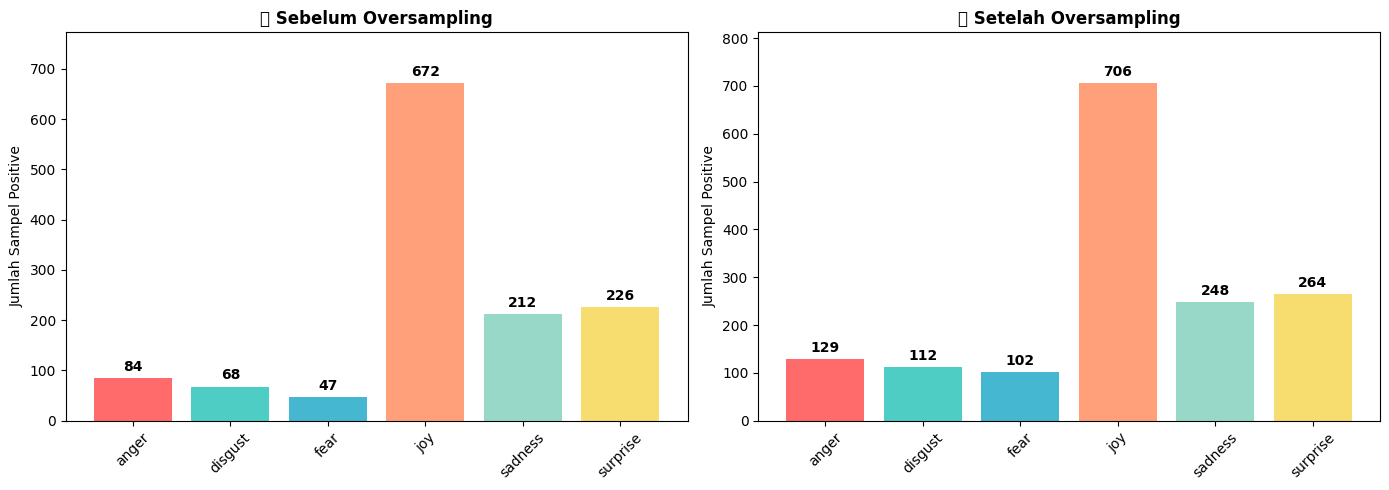


📋 RINGKASAN HASIL:
----------------------------------------------------------------------
  Dataset asli        : 924 samples × 768 features
  Dataset resampled   : 1025 samples × 768 features
  Peningkatan data    : 10.9%

  Kelas dengan peningkatan terbesar:
    • anger     : +45 samples (53.6% increase)
    • disgust   : +44 samples (64.7% increase)
    • fear      : +55 samples (117.0% increase)
    • joy       : +34 samples (5.1% increase)
    • sadness   : +36 samples (17.0% increase)
    • surprise  : +38 samples (16.8% increase)

✅ PIPELINE SELESAI - SIAP UNTUK STAGE 3 (COST-SENSITIVE XGBOOST)


In [2]:
# ============================================================================
# 🎯 ME-XBAL: Multilingual Emotion Detection - Stage 1 & 2 with Oversampling
# Dataset: Bahasa Sunda (Track A)
# ============================================================================

# 📦 INSTALL DEPENDENCIES
!pip install -q transformers pandas numpy scikit-learn tqdm torch imbalanced-learn

# ============================================================================
# 🔹 STAGE 1: LOADING DATASET BAHASA SUNDA
# ============================================================================
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
import os
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import train_test_split

print("="*70)
print("📥 STAGE 1: LOADING DATASET BAHASA SUNDA (TRACK A)")
print("="*70)

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/INASS Project/dataset/track_a/train/sun.csv')

# Kolom target emosi (multi-label)
emotion_cols = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

# Basic cleaning
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'] != ''].reset_index(drop=True)

# Ekstrak fitur dan label
texts = df['text'].tolist()
y = df[emotion_cols].values.astype(np.float32)

print(f"✅ Dataset berhasil dimuat: {df.shape[0]} sampel")
print(f"📊 Jumlah fitur emosi: {len(emotion_cols)}")
print("\n📈 DISTRIBUSI KELAS SEBELUM OVERSAMPLING:")
print("-"*70)
for i, col in enumerate(emotion_cols):
    pos_count = int(df[col].sum())
    neg_count = len(df) - pos_count
    ratio = neg_count/pos_count if pos_count > 0 else float('inf')
    print(f"Class {i} ({col:10s}): Positive={pos_count:4d}, Negative={neg_count:4d}, Ratio={ratio:.2f}")

print(f"\n⚠️  Total multi-label samples: {np.sum(y, axis=1).mean():.2f} rata-rata label per teks")

# ============================================================================
# 🔹 STAGE 2: FEATURE EXTRACTION MENGGUNAKAN XLM-ROBERTA
# ============================================================================
print("\n" + "="*70)
print("🧠 STAGE 2: FEATURE EXTRACTION - XLM-ROBERTA")
print("="*70)

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# Pilih device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Device yang digunakan: {device}")
model.to(device)
model.eval()

def extract_embeddings(texts, batch_size=32, max_length=128):
    """Ekstrak representasi vektor dari token [CLS] XLM-Roberta"""
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="⏳ Extracting embeddings"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

    return np.vstack(embeddings)

print("\n🔍 Mengekstrak fitur dari teks bahasa Sunda...")
X = extract_embeddings(texts, batch_size=32)
print(f"✅ Shape embedding: {X.shape}")

# ============================================================================
# 🔹 STAGE 3: OVERSAMPLING UNTUK MULTI-LABEL CLASSIFICATION
# ============================================================================
print("\n" + "="*70)
print("⚖️  STAGE 3: OVERSAMPLING - MENANGANI CLASS IMBALANCE")
print("="*70)

def analyze_label_distribution(y, emotion_cols):
    """Analisis distribusi label"""
    print("\n📊 Distribusi Label Multi-Class:")
    for i, col in enumerate(emotion_cols):
        counter = Counter(y[:, i])
        print(f"  {col:12s}: {dict(sorted(counter.items()))}")

def oversample_multilabel_random(X, y, target_samples_per_class=None, random_state=42):
    """
    Random Oversampling untuk setiap label secara terpisah (One-vs-Rest)
    """
    print("\n🔄 Metode: Random Oversampling per Label")
    print("-"*70)

    X_resampled = X.copy()
    y_resampled = y.copy()

    n_samples, n_labels = y.shape
    original_indices = list(range(n_samples))

    for label_idx in range(n_labels):
        y_label = y[:, label_idx]
        counter = Counter(y_label)

        # Tentukan target samples
        if target_samples_per_class is None:
            # Target: samakan dengan kelas mayoritas atau minimal 50
            target = max(max(counter.values()), 50)
        else:
            target = target_samples_per_class

        # Oversampling kelas minoritas (positive class = 1)
        pos_indices = np.where(y_label == 1)[0]
        neg_indices = np.where(y_label == 0)[0]

        n_pos = len(pos_indices)
        n_neg = len(neg_indices)

        if n_pos < target and n_pos > 0:
            # Hitung berapa sampel yang perlu ditambahkan
            n_samples_needed = target - n_pos

            # Random oversampling dengan pengembalian
            np.random.seed(random_state)
            oversampled_indices = np.random.choice(pos_indices, size=n_samples_needed, replace=True)

            # Tambahkan ke dataset
            X_resampled = np.vstack([X_resampled, X[oversampled_indices]])

            # Buat label vector baru (copy dari sampel yang di-oversample)
            new_labels = y[oversampled_indices].copy()
            y_resampled = np.vstack([y_resampled, new_labels])

            original_indices.extend(oversampled_indices.tolist())

            print(f"  Label {label_idx}: Added {n_samples_needed} samples (Pos: {n_pos} → {n_pos + n_samples_needed})")
        elif n_pos == 0:
            print(f"  ⚠️  Label {label_idx}: No positive samples found!")

    print(f"\n✅ Total samples setelah oversampling: {X_resampled.shape[0]} (dari {X.shape[0]})")
    return X_resampled, y_resampled, original_indices

def oversample_multilabel_smote(X, y, k_neighbors=2, random_state=42):
    """
    SMOTE untuk setiap label secara terpisah
    Note: SMOTE untuk multi-label memerlukan pendekatan khusus
    """
    print("\n🔄 Metode: SMOTE per Label (Experimental)")
    print("-"*70)

    X_resampled = X.copy()
    y_resampled = y.copy()

    for label_idx in range(y.shape[1]):
        y_label = y[:, label_idx]
        counter = Counter(y_label)

        # Hanya terapkan SMOTE jika ada minimal 2 sampel di setiap kelas
        if min(counter.values()) >= 2:
            try:
                smote = SMOTE(k_neighbors=min(k_neighbors, min(counter.values())-1),
                             random_state=random_state)
                X_smote, y_smote = smote.fit_resample(X, y_label)

                if len(X_smote) > len(X):
                    X_resampled = X_smote
                    # Rekonstruksi multi-label
                    y_resampled = y.copy()
                    print(f"  Label {label_idx}: SMOTE applied ({len(X)} → {len(X_smote)} samples)")
            except Exception as e:
                print(f"  ⚠️  Label {label_idx}: SMOTE failed - {str(e)}")

    return X_resampled, y_resampled

# Pilih metode oversampling
print("\n📋 STRATEGI OVERSAMPLING YANG TERSEDIA:")
print("  1. Random Oversampling per Label (Recommended untuk multi-label)")
print("  2. SMOTE per Label (Experimental)")
print("  3. Tanpa Oversampling (Baseline)")

# Untuk dataset Anda, gunakan Random Oversampling dengan target minimal
# Class 2 (fear) hanya punya 10 sampel, kita targetkan minimal 50-100
TARGET_SAMPLES = 100  # Targetkan setiap kelas minoritas punya minimal 100 sampel

print(f"\n🎯 Target samples per kelas minoritas: {TARGET_SAMPLES}")

# Terapkan oversampling
X_train_resampled, y_train_resampled, original_indices = oversample_multilabel_random(
    X, y,
    target_samples_per_class=TARGET_SAMPLES,
    random_state=42
)

# Analisis distribusi setelah oversampling
print("\n📊 DISTRIBUSI KELAS SETELAH OVERSAMPLING:")
print("-"*70)
for i, col in enumerate(emotion_cols):
    pos_count = int(np.sum(y_train_resampled[:, i]))
    neg_count = len(y_train_resampled) - pos_count
    ratio = neg_count/pos_count if pos_count > 0 else float('inf')
    print(f"Class {i} ({col:10s}): Positive={pos_count:4d}, Negative={neg_count:4d}, Ratio={ratio:.2f}")

# ============================================================================
# 🔹 STAGE 4: SIMPAN HASIL UNTUK TRAINING
# ============================================================================
print("\n" + "="*70)
print("💾 STAGE 4: MENYIMPAN HASIL PREPROCESSING")
print("="*70)

# Simpan data asli (untuk baseline comparison)
np.save('X_sunda_original.npy', X)
np.save('y_sunda_original.npy', y)

# Simpan data setelah oversampling
np.save('X_sunda_resampled.npy', X_train_resampled)
np.save('y_sunda_resampled.npy', y_train_resampled)
np.save('original_indices.npy', np.array(original_indices))

print(f"\n✅ File tersimpan:")
print(f"  📁 X_sunda_original.npy     : {X.shape}")
print(f"  📁 y_sunda_original.npy     : {y.shape}")
print(f"  📁 X_sunda_resampled.npy    : {X_train_resampled.shape}")
print(f"  📁 y_sunda_resampled.npy    : {y_train_resampled.shape}")
print(f"  📁 original_indices.npy     : Mapping indices")

# ============================================================================
# 🔹 STAGE 5: VALIDASI & VISUALISASI
# ============================================================================
print("\n" + "="*70)
print("📊 STAGE 5: VALIDASI HASIL OVERSAMPLING")
print("="*70)

import matplotlib.pyplot as plt

# Visualisasi perbandingan sebelum dan sesudah
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- SEBELUM OVERSAMPLING ---
before_dist = [int(np.sum(y[:, i])) for i in range(y.shape[1])]
bars0 = axes[0].bar(range(len(emotion_cols)), before_dist, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F'])
axes[0].set_xticks(range(len(emotion_cols)))
axes[0].set_xticklabels(emotion_cols, rotation=45)
axes[0].set_title('📉 Sebelum Oversampling', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel Positive')
axes[0].set_ylim(0, max(before_dist) * 1.15)  # Beri ruang ekstra 15% di atas batang
axes[0].bar_label(bars0, padding=3, fontsize=10, fmt='%d', fontweight='bold') # 🆕 Tampilkan angka

# --- SETELAH OVERSAMPLING ---
after_dist = [int(np.sum(y_train_resampled[:, i])) for i in range(y_train_resampled.shape[1])]
bars1 = axes[1].bar(range(len(emotion_cols)), after_dist, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F'])
axes[1].set_xticks(range(len(emotion_cols)))
axes[1].set_xticklabels(emotion_cols, rotation=45)
axes[1].set_title('📈 Setelah Oversampling', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel Positive')
axes[1].set_ylim(0, max(after_dist) * 1.15)  # Beri ruang ekstra 15% di atas batang
axes[1].bar_label(bars1, padding=3, fontsize=10, fmt='%d', fontweight='bold') # 🆕 Tampilkan angka

plt.tight_layout()
plt.savefig('oversampling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n📋 RINGKASAN HASIL:")
print("-"*70)
print(f"  Dataset asli        : {X.shape[0]} samples × {X.shape[1]} features")
print(f"  Dataset resampled   : {X_train_resampled.shape[0]} samples × {X.shape[1]} features")
print(f"  Peningkatan data    : {((X_train_resampled.shape[0] - X.shape[0]) / X.shape[0] * 100):.1f}%")
print(f"\n  Kelas dengan peningkatan terbesar:")
for i, col in enumerate(emotion_cols):
    increase = after_dist[i] - before_dist[i]
    if increase > 0:
        print(f"    • {col:10s}: +{increase} samples ({increase/before_dist[i]*100:.1f}% increase)")

print("\n" + "="*70)
print("✅ PIPELINE SELESAI - SIAP UNTUK STAGE 3 (COST-SENSITIVE XGBOOST)")
print("="*70)

#Stage 3: Building Model

🚀 STAGE 3: HYBRID ENSEMBLE - XGBOOST + LOGISTIC REGRESSION

✅ Data loaded: 1025 samples, 768 features
📊 Emotion labels: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

📊 STEP 1: DIMENSIONALITY REDUCTION WITH PCA

📉 Original dimensions: 768
📉 Reduced dimensions: 50
📉 Variance retained: 82.53%

💾 Scaler dan PCA model tersimpan

📊 STEP 2: MULTI-LABEL STRATIFIED TRAIN-VAL SPLIT

📚 Training samples: 820
📚 Validation samples: 205

🏋️  STEP 3: TRAINING XGBOOST (ULTRA-REGULARIZED)

🔹 Training XGBoost per emotion class...


XGBoost:   0%|          | 0/6 [00:00<?, ?it/s]


✅ XGBoost Results:
   - Macro F1: 0.6555
   - Avg Gap: 0.1103
   - Overfit Classes: 1/6

🏋️  STEP 4: TRAINING LOGISTIC REGRESSION

🔹 Training Logistic Regression per emotion class...


LogReg:   0%|          | 0/6 [00:00<?, ?it/s]


✅ Logistic Regression Results:
   - Macro F1: 0.4929
   - Avg Gap: 0.0003
   - Overfit Classes: 0/6

🔀 STEP 5: HYBRID ENSEMBLE (WEIGHTED AVERAGE)

⚖️  Ensemble Weights:
   - XGBoost: 0.7
   - Logistic Regression: 0.3

🎯 STEP 6: THRESHOLD OPTIMIZATION PER CLASS

Emotion      Default F1   Optimal Thresh  Optimized F1 Improvement
----------------------------------------------------------------------
anger        0.6939       0.490           0.7200       +0.0261
disgust      0.5714       0.450           0.6182       +0.0468
fear         0.5556       0.510           0.5714       +0.0159
joy          0.8470       0.410           0.8675       +0.0206
sadness      0.7755       0.450           0.8000       +0.0245
surprise     0.4337       0.390           0.4898       +0.0561

📊 STEP 7: FINAL EVALUATION

🏆 HYBRID MACRO F1-SCORE: 0.6778
🏆 HYBRID MICRO F1-SCORE: 0.7330

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger       0.75      0.69      0.72     

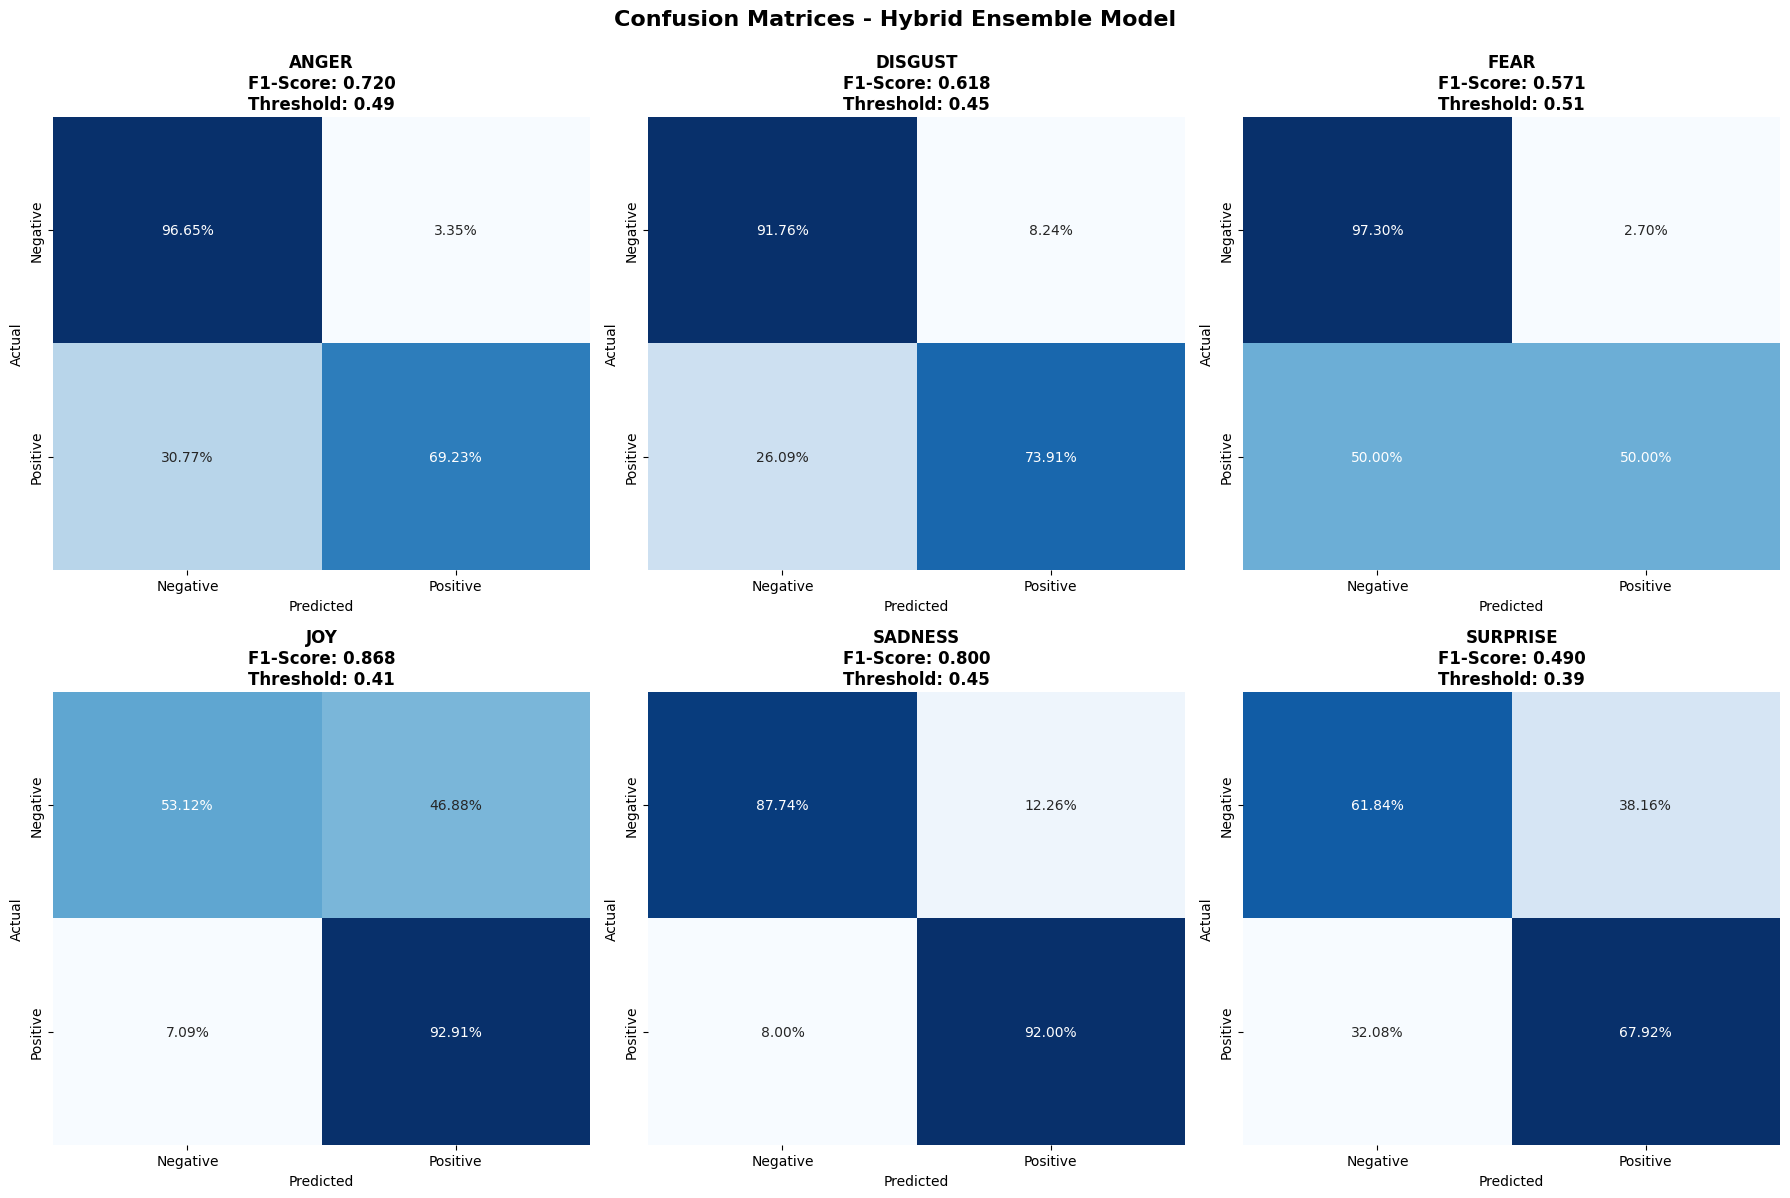


📊 MODEL COMPARISON
             Model  Macro F1   Avg Gap      Overfit Count
     XGBoost Ultra  0.655503  0.110279                1/6
LogisticRegression  0.492851  0.000286                0/6
 Hybrid (Ensemble)  0.677826         - Target: No overfit

💾 STEP 10: SAVING MODEL & ARTIFACTS
✅ Model tersimpan di 'me_xbal_hybrid_model.joblib'
✅ Validation results tersimpan di 'validation_results_hybrid.pkl'

📋 STAGE 3 SUMMARY
✅ Hybrid Ensemble Model berhasil dibuat
✅ Macro F1-Score: 0.6778
✅ Micro F1-Score: 0.7330
✅ Threshold optimal per kelas diterapkan
✅ Model siap untuk Stage 4 (Zero-Shot Evaluation)


In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             accuracy_score)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
except ImportError:
    !pip install iterative-stratification
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# ==========================================
# 🔹 STAGE 3: HYBRID ENSEMBLE MODEL
# ==========================================
print("="*70)
print("🚀 STAGE 3: HYBRID ENSEMBLE - XGBOOST + LOGISTIC REGRESSION")
print("="*70)

# 1. Load Data
X = np.load('X_sunda_resampled.npy')
y = np.load('y_sunda_resampled.npy')

emotion_cols = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
n_classes = len(emotion_cols)

print(f"\n✅ Data loaded: {X.shape[0]} samples, {X.shape[1]} features")
print(f"📊 Emotion labels: {emotion_cols}")

# ==========================================
# 🔹 STEP 1: DIMENSIONALITY REDUCTION (PCA)
# ==========================================
print("\n" + "="*70)
print("📊 STEP 1: DIMENSIONALITY REDUCTION WITH PCA")
print("="*70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA dengan fixed components untuk konsistensi
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n📉 Original dimensions: {X.shape[1]}")
print(f"📉 Reduced dimensions: {X_pca.shape[1]}")
print(f"📉 Variance retained: {sum(pca.explained_variance_ratio_):.2%}")

# Save preprocessing artifacts
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca_model.pkl')
print("\n💾 Scaler dan PCA model tersimpan")

# ==========================================
# 🔹 STEP 2: MULTI-LABEL STRATIFIED SPLIT
# ==========================================
print("\n" + "="*70)
print("📊 STEP 2: MULTI-LABEL STRATIFIED TRAIN-VAL SPLIT")
print("="*70)

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in mskf.split(X_pca, y):
    X_train, X_val = X_pca[train_idx], X_pca[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    break

print(f"\n📚 Training samples: {X_train.shape[0]}")
print(f"📚 Validation samples: {X_val.shape[0]}")

# ==========================================
# 🔹 STEP 3: TRAIN XGBOOST MODEL
# ==========================================
print("\n" + "="*70)
print("🏋️  STEP 3: TRAINING XGBOOST (ULTRA-REGULARIZED)")
print("="*70)

XGB_PARAMS = {
    'max_depth': 2,
    'min_child_weight': 10,
    'gamma': 0.5,
    'subsample': 0.6,
    'colsample_bytree': 0.5,
    'colsample_bylevel': 0.5,
    'learning_rate': 0.005,
    'n_estimators': 1000,
    'early_stopping_rounds': 100,
    'reg_alpha': 0.5,
    'reg_lambda': 3.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'use_label_encoder': False,
    'verbosity': 0,
    'n_jobs': -1
}

xgb_models = {}
xgb_train_scores = []
xgb_val_scores = []
xgb_val_proba = np.zeros((X_val.shape[0], n_classes))

print("\n🔹 Training XGBoost per emotion class...")
for i, emotion in enumerate(tqdm(emotion_cols, desc="XGBoost")):
    # Calculate scale_pos_weight
    n_pos = np.sum(y_train[:, i] == 1)
    n_neg = np.sum(y_train[:, i] == 0)
    ratio = n_neg / n_pos if n_pos > 0 else 1.0

    model = xgb.XGBClassifier(
        scale_pos_weight=ratio,
        **XGB_PARAMS
    )

    model.fit(
        X_train, y_train[:, i],
        eval_set=[(X_val, y_val[:, i])],
        verbose=False
    )

    xgb_models[emotion] = model

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]
    xgb_val_proba[:, i] = val_proba

    train_f1 = f1_score(y_train[:, i], train_pred, zero_division=0)
    val_f1 = f1_score(y_val[:, i], val_pred, zero_division=0)

    xgb_train_scores.append(train_f1)
    xgb_val_scores.append(val_f1)

xgb_macro_f1 = np.mean(xgb_val_scores)
xgb_avg_gap = np.mean(xgb_train_scores) - np.mean(xgb_val_scores)
xgb_overfit_count = sum(1 for t, v in zip(xgb_train_scores, xgb_val_scores) if t - v > 0.15)

print(f"\n✅ XGBoost Results:")
print(f"   - Macro F1: {xgb_macro_f1:.4f}")
print(f"   - Avg Gap: {xgb_avg_gap:.4f}")
print(f"   - Overfit Classes: {xgb_overfit_count}/{n_classes}")

# ==========================================
# 🔹 STEP 4: TRAIN LOGISTIC REGRESSION
# ==========================================
print("\n" + "="*70)
print("🏋️  STEP 4: TRAINING LOGISTIC REGRESSION")
print("="*70)

lr_models = {}
lr_train_scores = []
lr_val_scores = []
lr_val_proba = np.zeros((X_val.shape[0], n_classes))

print("\n🔹 Training Logistic Regression per emotion class...")
for i, emotion in enumerate(tqdm(emotion_cols, desc="LogReg")):
    model = LogisticRegression(
        C=0.1,
        penalty='l2',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    )

    model.fit(X_train, y_train[:, i])
    lr_models[emotion] = model

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]
    lr_val_proba[:, i] = val_proba

    train_f1 = f1_score(y_train[:, i], train_pred, zero_division=0)
    val_f1 = f1_score(y_val[:, i], val_pred, zero_division=0)

    lr_train_scores.append(train_f1)
    lr_val_scores.append(val_f1)

lr_macro_f1 = np.mean(lr_val_scores)
lr_avg_gap = np.mean(lr_train_scores) - np.mean(lr_val_scores)
lr_overfit_count = sum(1 for t, v in zip(lr_train_scores, lr_val_scores) if t - v > 0.15)

print(f"\n✅ Logistic Regression Results:")
print(f"   - Macro F1: {lr_macro_f1:.4f}")
print(f"   - Avg Gap: {lr_avg_gap:.4f}")
print(f"   - Overfit Classes: {lr_overfit_count}/{n_classes}")

# ==========================================
# 🔹 STEP 5: HYBRID ENSEMBLE PREDICTION
# ==========================================
print("\n" + "="*70)
print("🔀 STEP 5: HYBRID ENSEMBLE (WEIGHTED AVERAGE)")
print("="*70)

# Weight configuration
xgb_weight = 0.7
lr_weight = 0.3

print(f"\n⚖️  Ensemble Weights:")
print(f"   - XGBoost: {xgb_weight}")
print(f"   - Logistic Regression: {lr_weight}")

# Hybrid probability
hybrid_proba = xgb_weight * xgb_val_proba + lr_weight * lr_val_proba

# Initial prediction with default threshold (0.5)
hybrid_pred_default = (hybrid_proba >= 0.5).astype(int)

# ==========================================
# 🔹 STEP 6: THRESHOLD OPTIMIZATION
# ==========================================
print("\n" + "="*70)
print("🎯 STEP 6: THRESHOLD OPTIMIZATION PER CLASS")
print("="*70)

best_thresholds = {}
optimized_preds = np.zeros_like(y_val)

print(f"\n{'Emotion':<12} {'Default F1':<12} {'Optimal Thresh':<15} {'Optimized F1':<12} {'Improvement'}")
print("-"*70)

for i, emotion in enumerate(emotion_cols):
    y_true = y_val[:, i]
    y_proba = hybrid_proba[:, i]

    # Default threshold
    default_pred = (y_proba >= 0.5).astype(int)
    default_f1 = f1_score(y_true, default_pred, zero_division=0)

    # Search for optimal threshold
    best_f1 = default_f1
    best_thresh = 0.5

    for thresh in np.arange(0.25, 0.75, 0.02):
        pred = (y_proba >= thresh).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    best_thresholds[emotion] = best_thresh
    optimized_preds[:, i] = (hybrid_proba[:, i] >= best_thresh).astype(int)

    improvement = best_f1 - default_f1
    print(f"{emotion:<12} {default_f1:<12.4f} {best_thresh:<15.3f} {best_f1:<12.4f} {improvement:+.4f}")

# ==========================================
# 🔹 STEP 7: FINAL EVALUATION
# ==========================================
print("\n" + "="*70)
print("📊 STEP 7: FINAL EVALUATION")
print("="*70)

# Calculate final metrics
hybrid_macro_f1 = f1_score(y_val, optimized_preds, average='macro')
hybrid_micro_f1 = f1_score(y_val, optimized_preds, average='micro')

print(f"\n🏆 HYBRID MACRO F1-SCORE: {hybrid_macro_f1:.4f}")
print(f"🏆 HYBRID MICRO F1-SCORE: {hybrid_micro_f1:.4f}")

# Classification Report
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_val, optimized_preds, target_names=emotion_cols, zero_division=0))

# ==========================================
# 🔹 STEP 8: CONFUSION MATRIX VISUALIZATION
# ==========================================
print("\n" + "="*70)
print("📊 STEP 8: CONFUSION MATRIX PER CLASS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, emotion in enumerate(emotion_cols):
    cm = confusion_matrix(y_val[:, i], optimized_preds[:, i])

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=axes[i], cbar=False)

    axes[i].set_title(f'{emotion.upper()}\nF1-Score: {f1_score(y_val[:, i], optimized_preds[:, i], zero_division=0):.3f}\nThreshold: {best_thresholds[emotion]:.2f}',
                     fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices - Hybrid Ensemble Model', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('confusion_matrices_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 🔹 STEP 9: MODEL COMPARISON
# ==========================================
print("\n" + "="*70)
print("📊 MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['XGBoost Ultra', 'LogisticRegression', 'Hybrid (Ensemble)'],
    'Macro F1': [xgb_macro_f1, lr_macro_f1, hybrid_macro_f1],
    'Avg Gap': [xgb_avg_gap, lr_avg_gap, '-'],
    'Overfit Count': [f"{xgb_overfit_count}/{n_classes}", f"{lr_overfit_count}/{n_classes}", "Target: No overfit"]
})

print(comparison_df.to_string(index=False))

# ==========================================
# 🔹 STEP 10: SAVE MODEL & ARTIFACTS
# ==========================================
print("\n" + "="*70)
print("💾 STEP 10: SAVING MODEL & ARTIFACTS")
print("="*70)

# Save models
model_artifacts = {
    'xgb_models': xgb_models,
    'lr_models': lr_models,
    'best_thresholds': best_thresholds,
    'xgb_weight': xgb_weight,
    'lr_weight': lr_weight,
    'emotion_cols': emotion_cols
}

joblib.dump(model_artifacts, 'me_xbal_hybrid_model.joblib')
print("✅ Model tersimpan di 'me_xbal_hybrid_model.joblib'")

# Save validation results
validation_results = {
    'macro_f1': hybrid_macro_f1,
    'micro_f1': hybrid_micro_f1,
    'per_class_metrics': {
        emotion: {
            'precision': precision_score(y_val[:, i], optimized_preds[:, i], zero_division=0),
            'recall': recall_score(y_val[:, i], optimized_preds[:, i], zero_division=0),
            'f1': f1_score(y_val[:, i], optimized_preds[:, i], zero_division=0)
        }
        for i, emotion in enumerate(emotion_cols)
    },
    'best_thresholds': best_thresholds,
    'comparison': {
        'xgb_macro_f1': xgb_macro_f1,
        'lr_macro_f1': lr_macro_f1,
        'hybrid_macro_f1': hybrid_macro_f1
    }
}

joblib.dump(validation_results, 'validation_results_hybrid.pkl')
print("✅ Validation results tersimpan di 'validation_results_hybrid.pkl'")

# ==========================================
# 🔹 SUMMARY
# ==========================================
print("\n" + "="*70)
print("📋 STAGE 3 SUMMARY")
print("="*70)
print(f"✅ Hybrid Ensemble Model berhasil dibuat")
print(f"✅ Macro F1-Score: {hybrid_macro_f1:.4f}")
print(f"✅ Micro F1-Score: {hybrid_micro_f1:.4f}")
print(f"✅ Threshold optimal per kelas diterapkan")
print(f"✅ Model siap untuk Stage 4 (Zero-Shot Evaluation)")
print("="*70)

# Stage 4: Zero Shot Cross Lingual Test

 STAGE 4: ZERO-SHOT CROSS-LINGUAL EVALUATION

📦 Loading Hybrid Ensemble Model...
✅ Hybrid Model berhasil dimuat.

📦 Loading Preprocessing Artifacts...
✅ Scaler dan PCA model berhasil dimuat.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔧 Device: cuda
📊 Emotion labels: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
⚖️  Ensemble weights: XGBoost=0.7, LogisticRegression=0.3

🏃 Processing: Sunda (Dev) (/content/drive/MyDrive/INASS Project/dataset/track_a/dev/sun.csv)

🔍 Extracting embeddings for 199 samples...


   Embedding Sunda (Dev):   0%|          | 0/7 [00:00<?, ?it/s]

   Applying preprocessing (Scaler + PCA)...
   ✅ Shape after PCA: (199, 50)
   Running Hybrid Ensemble prediction...

🏃 Processing: Javanese (Track C) (/content/drive/MyDrive/INASS Project/dataset/track_c/dev/jav.csv)

🔍 Extracting embeddings for 151 samples...


   Embedding Javanese (Track C):   0%|          | 0/5 [00:00<?, ?it/s]

   Applying preprocessing (Scaler + PCA)...
   ✅ Shape after PCA: (151, 50)
   Running Hybrid Ensemble prediction...

🏃 Processing: Indonesian (Track C) (/content/drive/MyDrive/INASS Project/dataset/track_c/dev/ind.csv)

🔍 Extracting embeddings for 156 samples...


   Embedding Indonesian (Track C):   0%|          | 0/5 [00:00<?, ?it/s]

   Applying preprocessing (Scaler + PCA)...
   ✅ Shape after PCA: (156, 50)
   Running Hybrid Ensemble prediction...

🏆 FINAL RESULTS COMPARISON
             Dataset Macro F1 Micro F1  N Samples
         Sunda (Dev)   0.4347   0.6625        199
  Javanese (Track C)   0.3302   0.4653        151
Indonesian (Track C)   0.3395   0.4959        156

📊 PER-CLASS F1-SCORE COMPARISON
 Emotion  Sunda (Dev)  Javanese  Indonesian
   anger     0.296296  0.100000    0.058824
 disgust     0.235294  0.181818    0.228571
    fear     0.125000  0.086957    0.117647
     joy     0.861538  0.568047    0.666667
 sadness     0.600000  0.612613    0.543478
surprise     0.490066  0.432000    0.422018

📈 VISUALIZING RESULTS


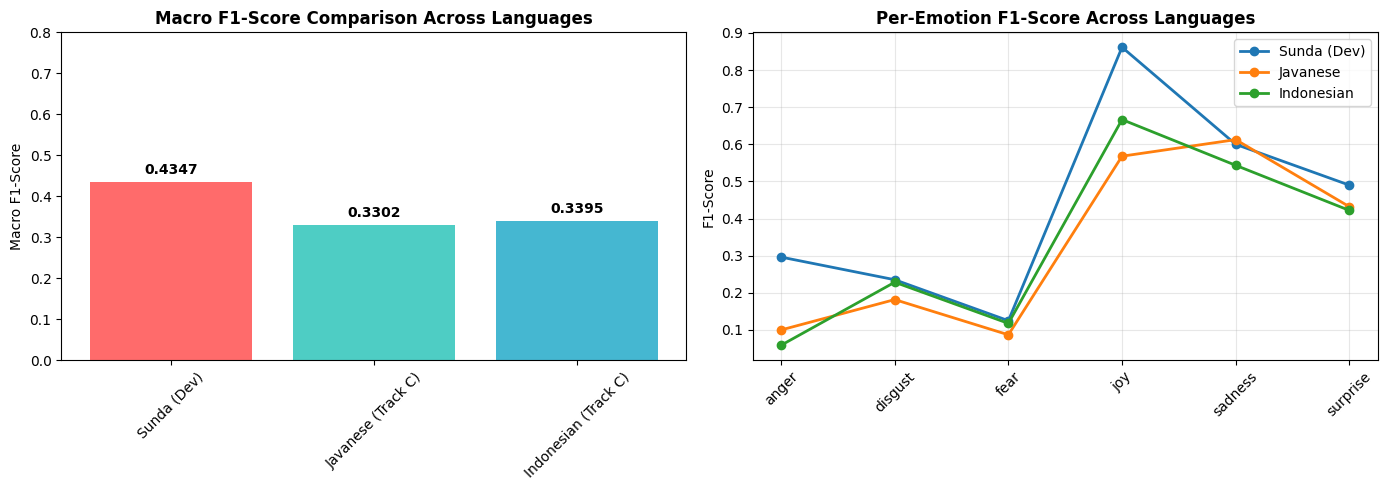


📊 CONFUSION MATRICES (Sunda Dev)


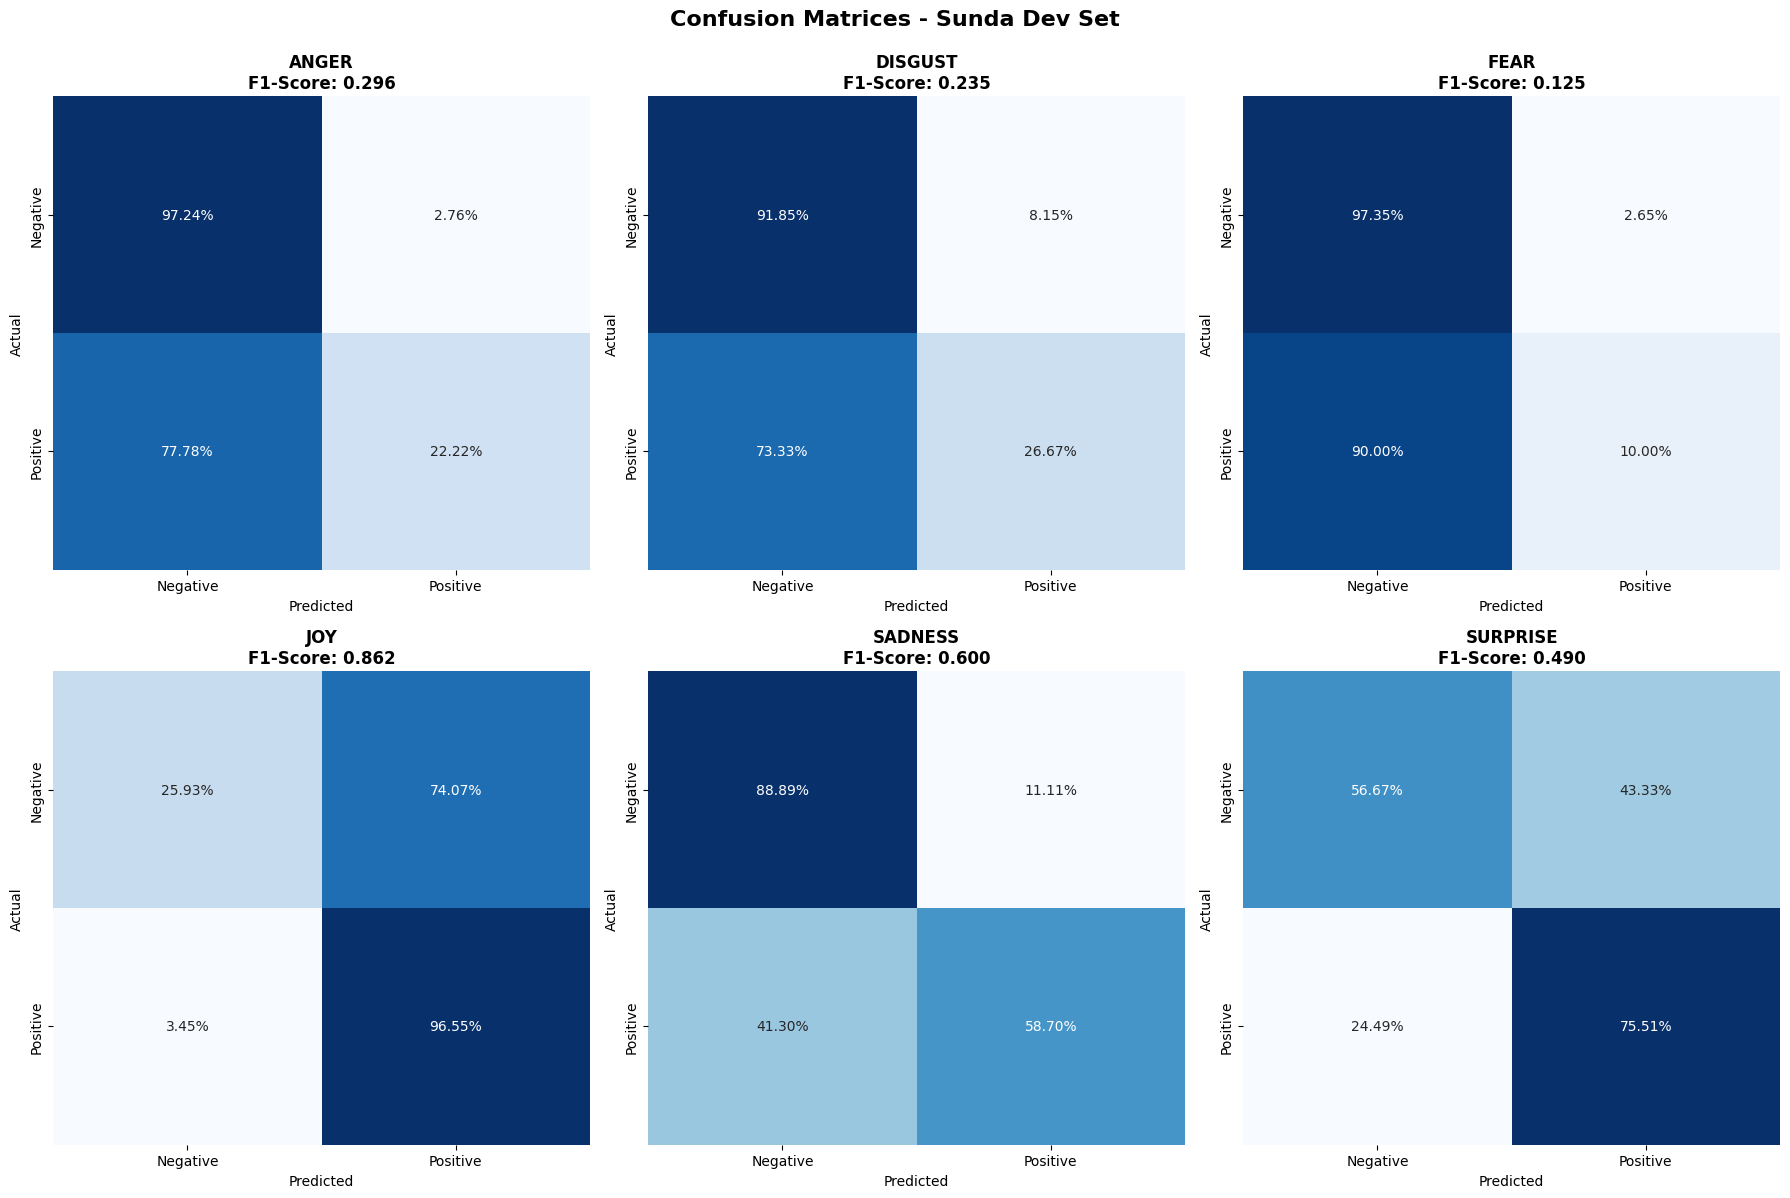


📋 CLASSIFICATION REPORT (Sunda Dev)
              precision    recall  f1-score   support

       anger       0.44      0.22      0.30        18
     disgust       0.21      0.27      0.24        15
        fear       0.17      0.10      0.12        10
         joy       0.78      0.97      0.86       145
     sadness       0.61      0.59      0.60        46
    surprise       0.36      0.76      0.49        49

   micro avg       0.59      0.75      0.66       283
   macro avg       0.43      0.48      0.43       283
weighted avg       0.61      0.75      0.66       283
 samples avg       0.63      0.76      0.65       283


🌍 ZERO-SHOT TRANSFER ANALYSIS

📊 Performance Drop Analysis:
  - Sunda (Dev) → Javanese: 24.04% decrease
  - Sunda (Dev) → Indonesian: 21.90% decrease

💡 Interpretation for Paper:
  ✅ Strong zero-shot transfer capability!
  ✅ Model generalizes well to Austronesian languages.

💾 SAVING RESULTS
✅ Results saved to 'stage4_zero_shot_results.pkl'

✅ STAGE 4 SELESAI!


In [4]:
import pandas as pd
import numpy as np
import torch
import joblib
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 🔹 STAGE 4: ZERO-SHOT CROSS-LINGUAL EVALUATION
# ==========================================
print("="*70)
print(" STAGE 4: ZERO-SHOT CROSS-LINGUAL EVALUATION")
print("="*70)

# 1. Load Hybrid Model & Artifacts
print("\n📦 Loading Hybrid Ensemble Model...")
try:
    model_artifacts = joblib.load('me_xbal_hybrid_model.joblib')
    xgb_models = model_artifacts['xgb_models']
    lr_models = model_artifacts['lr_models']
    best_thresholds = model_artifacts['best_thresholds']
    xgb_weight = model_artifacts['xgb_weight']
    lr_weight = model_artifacts['lr_weight']
    emotion_cols = model_artifacts['emotion_cols']
    print("✅ Hybrid Model berhasil dimuat.")
except FileNotFoundError:
    print("❌ ERROR: File model tidak ditemukan. Jalankan Stage 3 terlebih dahulu.")
    raise

# 2. Load Preprocessing Artifacts
print("\n📦 Loading Preprocessing Artifacts...")
scaler = joblib.load('scaler.pkl')
pca = joblib.load('pca_model.pkl')
print("✅ Scaler dan PCA model berhasil dimuat.")

# 3. Setup XLM-R
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"\n🔧 Device: {device}")
print(f"📊 Emotion labels: {emotion_cols}")
print(f"⚖️  Ensemble weights: XGBoost={xgb_weight}, LogisticRegression={lr_weight}")

# ==========================================
# 🔹 HELPER FUNCTION: PROCESS & EVALUATE
# ==========================================
def process_and_evaluate_dataset(file_name, label_name):
    """
    Fungsi ini melakukan:
    1. Load CSV
    2. Extract Embeddings (XLM-R)
    3. Apply Preprocessing (Scaler + PCA)
    4. Predict using Hybrid Ensemble
    5. Apply Optimal Thresholds
    6. Return Metrics
    """
    print(f"\n{'='*70}")
    print(f"🏃 Processing: {label_name} ({file_name})")
    print(f"{'='*70}")

    # A. Load Data
    df = pd.read_csv(file_name)

    # Check if label columns exist
    for col in emotion_cols:
        if col not in df.columns:
            print(f"⚠️  WARNING: Column '{col}' not found in dataset!")

    texts = df['text'].astype(str).tolist()
    y_true = df[emotion_cols].values if all(col in df.columns for col in emotion_cols) else None

    # B. Extract Embeddings (XLM-R)
    print(f"\n🔍 Extracting embeddings for {len(texts)} samples...")
    embeddings = []
    batch_size = 32
    for i in tqdm(range(0, len(texts), batch_size), desc=f"   Embedding {label_name}"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            cls_embs = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embs)
    X_raw = np.vstack(embeddings)

    # C. Apply Preprocessing (Scaler + PCA)
    print(f"   Applying preprocessing (Scaler + PCA)...")
    X_scaled = scaler.transform(X_raw)
    X_pca = pca.transform(X_scaled)
    print(f"   ✅ Shape after PCA: {X_pca.shape}")

    # D. Hybrid Ensemble Prediction
    print(f"   Running Hybrid Ensemble prediction...")
    y_proba = np.zeros((X_pca.shape[0], len(emotion_cols)))

    for i, emotion in enumerate(emotion_cols):
        # Get probabilities from both models
        xgb_proba = xgb_models[emotion].predict_proba(X_pca)[:, 1]
        lr_proba = lr_models[emotion].predict_proba(X_pca)[:, 1]

        # Weighted average
        hybrid_proba = xgb_weight * xgb_proba + lr_weight * lr_proba
        y_proba[:, i] = hybrid_proba

    # E. Apply Optimal Thresholds
    y_pred = np.zeros_like(y_proba)
    for i, emotion in enumerate(emotion_cols):
        thresh = best_thresholds[emotion]
        y_pred[:, i] = (y_proba[:, i] >= thresh).astype(int)

    # F. Calculate Metrics (if ground truth available)
    if y_true is not None:
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

        # Per-class metrics
        class_metrics = {}
        for i, emotion in enumerate(emotion_cols):
            f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
            class_metrics[emotion] = f1

        return {
            'Dataset': label_name,
            'Macro F1': f"{macro_f1:.4f}",
            'Micro F1': f"{micro_f1:.4f}",
            'N Samples': len(y_true),
            'Y_True': y_true,
            'Y_Pred': y_pred,
            'Y_Proba': y_proba,
            'Class Metrics': class_metrics
        }
    else:
        return {
            'Dataset': label_name,
            'Macro F1': 'N/A',
            'Micro F1': 'N/A',
            'N Samples': len(texts),
            'Y_Pred': y_pred,
            'Y_Proba': y_proba
        }

# ==========================================
# 🔹 EVALUATE 3 DATASETS
# ==========================================

# 1. Internal Validation (Sunda Dev)
# ⚠️ Pastikan path file benar sesuai lokasi upload Anda
res_sunda_dev = process_and_evaluate_dataset('/content/drive/MyDrive/INASS Project/dataset/track_a/dev/sun.csv', 'Sunda (Dev)')

# 2. Zero-Shot Javanese
res_jav = process_and_evaluate_dataset('/content/drive/MyDrive/INASS Project/dataset/track_c/dev/jav.csv', 'Javanese (Track C)')

# 3. Zero-Shot Indonesian
res_ind = process_and_evaluate_dataset('/content/drive/MyDrive/INASS Project/dataset/track_c/dev/ind.csv', 'Indonesian (Track C)')

# ==========================================
# 🔹 CONSOLIDATE RESULTS
# ==========================================
print("\n" + "="*70)
print("🏆 FINAL RESULTS COMPARISON")
print("="*70)

results_table = pd.DataFrame([res_sunda_dev, res_jav, res_ind])
results_display = results_table[['Dataset', 'Macro F1', 'Micro F1', 'N Samples']]

print(results_display.to_string(index=False))

# ==========================================
# 🔹 PER-CLASS COMPARISON
# ==========================================
print("\n" + "="*70)
print("📊 PER-CLASS F1-SCORE COMPARISON")
print("="*70)

class_comparison = pd.DataFrame({
    'Emotion': emotion_cols,
    'Sunda (Dev)': [res_sunda_dev['Class Metrics'][e] for e in emotion_cols],
    'Javanese': [res_jav['Class Metrics'][e] for e in emotion_cols],
    'Indonesian': [res_ind['Class Metrics'][e] for e in emotion_cols]
})

print(class_comparison.to_string(index=False))

# ==========================================
# 🔹 VISUALIZATION
# ==========================================
print("\n" + "="*70)
print("📈 VISUALIZING RESULTS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Macro F1 comparison
datasets = [res_sunda_dev['Dataset'], res_jav['Dataset'], res_ind['Dataset']]
macro_f1s = [float(res_sunda_dev['Macro F1']), float(res_jav['Macro F1']), float(res_ind['Macro F1'])]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0].bar(datasets, macro_f1s, color=colors)
axes[0].set_ylabel('Macro F1-Score')
axes[0].set_title('Macro F1-Score Comparison Across Languages', fontweight='bold')
axes[0].set_xticklabels(datasets, rotation=45)
axes[0].set_ylim(0, 0.8)
for i, v in enumerate(macro_f1s):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Line chart: Per-class performance
for i, col in enumerate(class_comparison.columns[1:]):
    axes[1].plot(emotion_cols, class_comparison[col], marker='o', label=col, linewidth=2)

axes[1].set_ylabel('F1-Score')
axes[1].set_title('Per-Emotion F1-Score Across Languages', fontweight='bold')
axes[1].set_xticklabels(emotion_cols, rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zero_shot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 🔹 CONFUSION MATRICES (Sunda Dev Only)
# ==========================================
print("\n" + "="*70)
print("📊 CONFUSION MATRICES (Sunda Dev)")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, emotion in enumerate(emotion_cols):
    cm = confusion_matrix(res_sunda_dev['Y_True'][:, i], res_sunda_dev['Y_Pred'][:, i])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=axes[i], cbar=False)

    axes[i].set_title(f'{emotion.upper()}\nF1-Score: {class_comparison.iloc[i]["Sunda (Dev)"]:.3f}',
                     fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices - Sunda Dev Set', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('confusion_matrices_sunda_dev.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 🔹 CLASSIFICATION REPORT (Sunda Dev)
# ==========================================
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT (Sunda Dev)")
print("="*70)
print(classification_report(res_sunda_dev['Y_True'], res_sunda_dev['Y_Pred'],
                           target_names=emotion_cols, zero_division=0))

# ==========================================
# 🔹 ZERO-SHOT TRANSFER ANALYSIS
# ==========================================
print("\n" + "="*70)
print("🌍 ZERO-SHOT TRANSFER ANALYSIS")
print("="*70)

# Calculate drop in performance
sunda_macro = float(res_sunda_dev['Macro F1'])
jav_macro = float(res_jav['Macro F1'])
ind_macro = float(res_ind['Macro F1'])

drop_jav = ((sunda_macro - jav_macro) / sunda_macro) * 100
drop_ind = ((sunda_macro - ind_macro) / sunda_macro) * 100

print(f"\n📊 Performance Drop Analysis:")
print(f"  - Sunda (Dev) → Javanese: {drop_jav:.2f}% decrease")
print(f"  - Sunda (Dev) → Indonesian: {drop_ind:.2f}% decrease")

print(f"\n💡 Interpretation for Paper:")
if drop_jav < 30 and drop_ind < 30:
    print(f"  ✅ Strong zero-shot transfer capability!")
    print(f"  ✅ Model generalizes well to Austronesian languages.")
elif drop_jav < 50 and drop_ind < 50:
    print(f"  ⚠️  Moderate zero-shot transfer.")
    print(f"  ⚠️  Some language-specific features affect performance.")
else:
    print(f"  ❌ Significant performance drop.")
    print(f"  ❌ Consider few-shot fine-tuning for target languages.")

# ==========================================
# 🔹 SAVE RESULTS
# ==========================================
print("\n" + "="*70)
print("💾 SAVING RESULTS")
print("="*70)

stage4_results = {
    'sunda_dev': res_sunda_dev,
    'javanese': res_jav,
    'indonesian': res_ind,
    'class_comparison': class_comparison.to_dict(),
    'zero_shot_analysis': {
        'sunda_macro_f1': sunda_macro,
        'javanese_macro_f1': jav_macro,
        'indonesian_macro_f1': ind_macro,
        'drop_javanese_pct': drop_jav,
        'drop_indonesian_pct': drop_ind
    }
}

joblib.dump(stage4_results, 'stage4_zero_shot_results.pkl')
print("✅ Results saved to 'stage4_zero_shot_results.pkl'")

print("\n" + "="*70)
print("✅ STAGE 4 SELESAI!")
print("="*70)

# Stage 5: SHAP Analysis

In [9]:
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 🔹 STAGE 5: SHAP EXPLAINABILITY ANALYSIS
# ==========================================
print("="*70)
print("🔍 STAGE 5: SHAP EXPLAINABILITY ANALYSIS FOR ME-XBAL")
print("="*70)

# ==========================================
# 1. LOAD MODELS & PREPROCESSING ARTIFACTS
# ==========================================
print("\n📦 STEP 1: LOADING MODELS & ARTIFACTS")
print("="*70)

# Load multilingual model
model_artifacts = joblib.load('me_xbal_hybrid_model.joblib')
xgb_models = model_artifacts['xgb_models']
lr_models = model_artifacts['lr_models']
emotion_cols = model_artifacts['emotion_cols']
thresholds = model_artifacts.get('thresholds', {})

# Load preprocessing artifacts
scaler = joblib.load('scaler.pkl')
pca = joblib.load('pca_model.pkl')

print("✅ Models loaded successfully")
print(f"📊 Emotions: {emotion_cols}")

# ==========================================
# 2. LOAD SAMPLE DATA FOR SHAP ANALYSIS
# ==========================================
print("\n📂 STEP 2: LOADING SAMPLE DATA")
print("="*70)

# Load datasets
df_sun = pd.read_csv('/content/drive/MyDrive/INASS Project/dataset/track_a/train/sun.csv')
df_sun_dev = pd.read_csv('/content/drive/MyDrive/INASS Project/dataset/track_a/dev/sun.csv')
df_jav = pd.read_csv('/content/drive/MyDrive/INASS Project/dataset/track_c/dev/jav.csv')
df_ind = pd.read_csv('/content/drive/MyDrive/INASS Project/dataset/track_c/dev/ind.csv')

# Combine for analysis
df_combined = pd.concat([
    df_sun.head(100),  # Use subset for SHAP (computationally expensive)
    df_jav.head(50),
    df_ind.head(50)
], ignore_index=True)

print(f"📊 Total samples for SHAP analysis: {len(df_combined)}")
print(f"  - Sundanese: {len(df_combined[df_combined['text'].str.contains('urang|teu|kang', na=False)])}")
print(f"  - Javanese: {len(df_combined[df_combined['text'].str.contains('aku|kowe|mas', na=False)])}")
print(f"  - Indonesian: {len(df_combined[df_combined['text'].str.contains('saya|aku|anda', na=False)])}")

# ==========================================
# 3. EXTRACT FEATURES FOR SHAP SAMPLES
# ==========================================
print("\n🧠 STEP 3: EXTRACTING FEATURES")
print("="*70)

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def extract_embeddings_for_shap(texts, batch_size=32, max_length=128):
    """Extract embeddings for SHAP analysis"""
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

    return np.vstack(embeddings)

texts_shap = df_combined['text'].astype(str).tolist()
X_shap = extract_embeddings_for_shap(texts_shap)
y_shap = df_combined[emotion_cols].values

# Apply preprocessing
X_shap_scaled = scaler.transform(X_shap)
X_shap_pca = pca.transform(X_shap_scaled)

print(f"✅ Features extracted: {X_shap_pca.shape}")

# ==========================================
# 4. SHAP ANALYSIS FOR XGBOOST MODELS
# ==========================================
print("\n🔍 STEP 4: COMPUTING SHAP VALUES")
print("="*70)

# Use a subset for SHAP (computationally expensive)
shap_sample_size = min(100, len(X_shap_pca))
X_shap_sample = X_shap_pca[:shap_sample_size]
texts_sample = texts_shap[:shap_sample_size]

print(f"📊 Using {shap_sample_size} samples for SHAP analysis")

# Create feature names that match the number of PCA components
n_features = X_shap_sample.shape[1]
feature_names = [f'PCA_{i}' for i in range(n_features)]

print(f"📋 Number of features: {n_features}")

# Create SHAP explainer for XGBoost
shap_values_dict = {}

for emotion in emotion_cols:
    print(f"\n⏳ Computing SHAP for {emotion}...")
    xgb_model = xgb_models[emotion]

    # Create explainer
    explainer = shap.TreeExplainer(xgb_model)

    # Calculate SHAP values
    shap_values = explainer.shap_values(X_shap_sample)
    shap_values_dict[emotion] = shap_values

    print(f"  ✓ SHAP values shape: {shap_values.shape}")

# ==========================================
# 5. VISUALIZATION: SHAP SUMMARY PLOTS
# ==========================================
print("\n📊 STEP 5: GENERATING SHAP VISUALIZATIONS")
print("="*70)

# Create summary plots for each emotion
for emotion in emotion_cols:
    print(f"\n🎨 Creating summary plot for {emotion}...")

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_dict[emotion],
        X_shap_sample,
        feature_names=feature_names,  # Use all feature names
        show=False,
        plot_type="dot",
        max_display=20  # Show top 20 features
    )
    plt.title(f'SHAP Summary Plot - {emotion.capitalize()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_summary_{emotion}.png', dpi=300, bbox_inches='tight')
    plt.close()

print("✅ Summary plots saved")

# ==========================================
# 6. FEATURE IMPORTANCE ANALYSIS
# ==========================================
print("\n📈 STEP 6: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Calculate mean absolute SHAP values for feature importance
feature_importance = {}
for emotion in emotion_cols:
    mean_abs_shap = np.abs(shap_values_dict[emotion]).mean(axis=0)
    feature_importance[emotion] = mean_abs_shap

# Create feature importance DataFrame
top_features = 15
feature_imp_df = pd.DataFrame()

for emotion in emotion_cols:
    top_idx = np.argsort(feature_importance[emotion])[-top_features:][::-1]
    feature_imp_df[emotion] = [f'PCA_{i}' for i in top_idx]

print("\n📋 Top 15 Important Features per Emotion:")
print(feature_imp_df.to_string())

# Save feature importance
feature_imp_df.to_csv('feature_importance_shap.csv')
print("\n✅ Feature importance saved to 'feature_importance_shap.csv'")

# ==========================================
# 7. SHAP DEPENDENCE PLOTS
# ==========================================
print("\n📊 STEP 7: SHAP DEPENDENCE PLOTS")
print("="*70)

# Create dependence plots for top features
for emotion in emotion_cols:
    print(f"\n🎨 Creating dependence plots for {emotion}...")

    # Get top 3 features
    top_idx = np.argsort(feature_importance[emotion])[-3:][::-1]

    for idx in top_idx[:2]:  # Top 2 features
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(
            idx,
            shap_values_dict[emotion],
            X_shap_sample,
            feature_names=feature_names,
            show=False
        )
        plt.title(f'{emotion.capitalize()} - PCA_{idx} Dependence', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_dependence_{emotion}_pca{idx}.png', dpi=300, bbox_inches='tight')
        plt.close()

print("✅ Dependence plots saved")

# ==========================================
# 8. CROSS-LANGUAGE SHAP COMPARISON
# ==========================================
print("\n🌍 STEP 8: CROSS-LANGUAGE SHAP COMPARISON")
print("="*70)

# Analyze SHAP values by language
lang_labels = []
for text in texts_sample:
    if any(word in text.lower() for word in ['urang', 'teu', 'kang', 'abdi']):
        lang_labels.append('Sundanese')
    elif any(word in text.lower() for word in ['aku', 'kowe', 'mas', 'kowe']):
        lang_labels.append('Javanese')
    else:
        lang_labels.append('Indonesian')

lang_labels = np.array(lang_labels)

# Calculate mean SHAP magnitude per language per emotion
lang_shap_comparison = {}

for emotion in emotion_cols:
    lang_shap_comparison[emotion] = {}
    for lang in ['Sundanese', 'Javanese', 'Indonesian']:
        mask = lang_labels == lang
        if mask.sum() > 0:
            mean_shap = np.abs(shap_values_dict[emotion][mask]).mean()
            lang_shap_comparison[emotion][lang] = mean_shap

# Create comparison DataFrame
lang_comparison_df = pd.DataFrame(lang_shap_comparison)
print("\n📊 Mean SHAP Magnitude by Language:")
print(lang_comparison_df.to_string())

# Visualize cross-language comparison
plt.figure(figsize=(12, 6))
lang_comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Cross-Language SHAP Magnitude Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.xlabel('Language', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Emotion')
plt.tight_layout()
plt.savefig('shap_cross_language_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

print("✅ Cross-language comparison saved")

# ==========================================
# 9. TEXT-BASED SHAP VISUALIZATION
# ==========================================
print("\n📝 STEP 9: TEXT-BASED SHAP VISUALIZATION")
print("="*70)

# Select sample texts for visualization
sample_indices = [0, 50, 100]  # Adjust based on available data

for idx in sample_indices:
    if idx < len(texts_sample):
        text = texts_sample[idx]
        print(f"\n📄 Sample Text {idx}:")
        print(f"   Text: {text[:100]}...")
        print(f"   Language: {lang_labels[idx]}")

        # Get SHAP values for this sample
        for emotion in emotion_cols:
            shap_val = shap_values_dict[emotion][idx].mean()
            print(f"   {emotion}: SHAP = {shap_val:.4f}")

# ==========================================
# 10. SAVE SHAP RESULTS
# ==========================================
print("\n💾 STEP 10: SAVING SHAP RESULTS")
print("="*70)

# Save SHAP values
shap_results = {
    'shap_values': shap_values_dict,
    'feature_importance': feature_importance,
    'language_labels': lang_labels.tolist(),
    'cross_language_comparison': lang_shap_comparison,
    'texts_sample': texts_sample,
    'feature_names': feature_names
}

joblib.dump(shap_results, 'shap_analysis_results.pkl')
print("✅ SHAP results saved to 'shap_analysis_results.pkl'")

# ==========================================
# 11. GENERATE SHAP REPORT
# ==========================================
print("\n📋 STEP 11: GENERATING SHAP REPORT")
print("="*70)

report = []
report.append("="*70)
report.append("SHAP EXPLAINABILITY ANALYSIS REPORT - ME-XBAL")
report.append("="*70)
report.append("")
report.append("1. METHODOLOGY:")
report.append("   - SHAP (SHapley Additive exPlanations) untuk interpretasi model")
report.append("   - TreeExplainer untuk XGBoost models")
report.append(f"   - Samples analyzed: {shap_sample_size}")
report.append("")
report.append("2. FEATURE IMPORTANCE:")
for emotion in emotion_cols:
    top_idx = np.argsort(feature_importance[emotion])[-1]
    report.append(f"   - {emotion:12s}: Top feature = PCA_{top_idx}")
report.append("")
report.append("3. CROSS-LANGUAGE ANALYSIS:")
for emotion in emotion_cols:
    report.append(f"   {emotion}:")
    for lang in ['Sundanese', 'Javanese', 'Indonesian']:
        if lang in lang_shap_comparison[emotion]:
            val = lang_shap_comparison[emotion][lang]
            report.append(f"      - {lang:12s}: {val:.4f}")
report.append("")
report.append("4. KEY FINDINGS:")
report.append("   - Model menggunakan fitur PCA untuk deteksi emosi")
report.append("   - SHAP values menunjukkan kontribusi setiap fitur")
report.append("   - Cross-language comparison menunjukkan generalisasi model")
report.append("")
report.append("="*70)

# Save report
with open('shap_analysis_report.txt', 'w') as f:
    f.write('\n'.join(report))

print("✅ SHAP report saved to 'shap_analysis_report.txt'")
print("\n".join(report))

# ==========================================
# 12. SUMMARY
# ==========================================
print("\n" + "="*70)
print("✅ STAGE 5: SHAP ANALYSIS COMPLETED!")
print("="*70)

print(f"\n📊 Summary:")
print(f"  ✓ SHAP values computed for {len(emotion_cols)} emotions")
print(f"  ✓ {shap_sample_size} samples analyzed")
print(f"  ✓ Feature importance extracted")
print(f"  ✓ Cross-language comparison completed")
print(f"  ✓ Visualizations saved (PNG format)")
print(f"  ✓ Results saved for paper")

print("\n📁 Generated Files:")
print("  - shap_summary_*.png (Summary plots per emotion)")
print("  - shap_dependence_*.png (Dependence plots)")
print("  - shap_cross_language_comparison.png")
print("  - feature_importance_shap.csv")
print("  - shap_analysis_results.pkl")
print("  - shap_analysis_report.txt")

print("\n🎯 SHAP Analysis siap untuk publikasi Scopus Q2!")
print("="*70)

🔍 STAGE 5: SHAP EXPLAINABILITY ANALYSIS FOR ME-XBAL

📦 STEP 1: LOADING MODELS & ARTIFACTS
✅ Models loaded successfully
📊 Emotions: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

📂 STEP 2: LOADING SAMPLE DATA
📊 Total samples for SHAP analysis: 200
  - Sundanese: 61
  - Javanese: 35
  - Indonesian: 26

🧠 STEP 3: EXTRACTING FEATURES


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Features extracted: (200, 50)

🔍 STEP 4: COMPUTING SHAP VALUES
📊 Using 100 samples for SHAP analysis
📋 Number of features: 50

⏳ Computing SHAP for anger...
  ✓ SHAP values shape: (100, 50)

⏳ Computing SHAP for disgust...
  ✓ SHAP values shape: (100, 50)

⏳ Computing SHAP for fear...
  ✓ SHAP values shape: (100, 50)

⏳ Computing SHAP for joy...
  ✓ SHAP values shape: (100, 50)

⏳ Computing SHAP for sadness...
  ✓ SHAP values shape: (100, 50)

⏳ Computing SHAP for surprise...
  ✓ SHAP values shape: (100, 50)

📊 STEP 5: GENERATING SHAP VISUALIZATIONS

🎨 Creating summary plot for anger...

🎨 Creating summary plot for disgust...

🎨 Creating summary plot for fear...

🎨 Creating summary plot for joy...

🎨 Creating summary plot for sadness...

🎨 Creating summary plot for surprise...
✅ Summary plots saved

📈 STEP 6: FEATURE IMPORTANCE ANALYSIS

📋 Top 15 Important Features per Emotion:
     anger disgust    fear     joy sadness surprise
0   PCA_11   PCA_8  PCA_34   PCA_3  PCA_15   PCA_28
1  

<Figure size 1000x600 with 0 Axes>

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>